# Notebook 11 - Medicion configs C, D y E (Claude + RAG) bidireccional

**Entrega 2 - Fase 6 (cierre).**

Mide las tres configuraciones del eje LLM sobre el mismo val set
usado en Notebook 10, en ambas direcciones:

- **Config C**: Claude Sonnet 4.6 zero-shot (sin RAG).
- **Config D**: Claude Sonnet 4.6 + RAG multi-indice (lexico + gramatical +
  ejemplos paralelos).
- **Config E**: Hibrido. LoRA produce un draft, Claude+RAG lo refina con el
  contexto recuperado. Solo se evalua si el LoRA y las predicciones B
  estan disponibles desde NB10.

Para `es2inga` el indice de ejemplos consultado es `ejemplos_es` (indexado
por texto espanol). Esto se logra cambiando el nombre del indice en el
retriever via monkey patch temporal (mas simple que duplicar la API).


In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import pandas as pd
from tqdm import tqdm

from src.models import claude_rag
from src.rag import retriever as retr_mod
from src.rag.indexes import search
from src.eval.metrics import all_metrics

VAL_N = 100

val = pd.read_json(ROOT / "datos" / "splits" / "val.jsonl", lines=True)
val_sample = val.sample(VAL_N, random_state=42).reset_index(drop=True)
print(f"Val sample: {len(val_sample)} pares")


Val sample: 100 pares


## Adaptador de retrieval segun direccion

Para `inga2es` usamos el indice estandar `ejemplos`. Para `es2inga` el
mismo retriever debe consultar `ejemplos_es`. Se reemplaza temporalmente
la funcion `retrieve` del retriever para que apunte al indice correcto
durante cada bloque de medicion.


In [2]:
def retrieve_dynamic(query: str, indice_ejemplos: str, top_k: int = 5):
    return retr_mod.RetrievedContext(
        query=query,
        lexico=search("lexico", query, top_k),
        gramatical=search("gramatical", query, top_k),
        ejemplos=search(indice_ejemplos, query, top_k),
    )


def translate_with_direction(sentence: str, direccion: str, use_rag: bool, top_k: int = 5) -> str:
    """Llama al pipeline Claude con el indice de ejemplos correcto segun direccion."""
    ctx = None
    if use_rag:
        indice = "ejemplos" if direccion == "inga2es" else "ejemplos_es"
        ctx = retrieve_dynamic(sentence, indice, top_k=top_k)
    prompt = claude_rag.build_prompt(sentence, ctx, direccion)
    system = (
        claude_rag.SYSTEM_PROMPT_INGA2ES if direccion == "inga2es"
        else claude_rag.SYSTEM_PROMPT_ES2INGA
    )
    client = claude_rag._get_client()
    resp = client.messages.create(
        model=claude_rag.DEFAULT_MODEL,
        max_tokens=claude_rag.DEFAULT_MAX_TOKENS,
        system=system,
        messages=[{"role": "user", "content": prompt}],
    )
    return resp.content[0].text.strip()


## Medir config C: Claude zero-shot, ambas direcciones

In [3]:
inga_sents = val_sample.texto_inga.tolist()
es_sents = val_sample.texto_es.tolist()

hyps_C_inga2es = [translate_with_direction(s, "inga2es", use_rag=False) for s in tqdm(inga_sents, desc="C inga2es")]
metrics_C_inga2es = all_metrics(es_sents, hyps_C_inga2es)
print(f"Config C inga2es: {metrics_C_inga2es}")

hyps_C_es2inga = [translate_with_direction(s, "es2inga", use_rag=False) for s in tqdm(es_sents, desc="C es2inga")]
metrics_C_es2inga = all_metrics(inga_sents, hyps_C_es2inga)
print(f"Config C es2inga: {metrics_C_es2inga}")


C inga2es:   0%|          | 0/100 [00:00<?, ?it/s]

C inga2es:   1%|          | 1/100 [00:05<09:13,  5.59s/it]

C inga2es:   2%|▏         | 2/100 [00:07<05:51,  3.59s/it]

C inga2es:   3%|▎         | 3/100 [00:10<05:07,  3.17s/it]

C inga2es:   4%|▍         | 4/100 [00:14<05:23,  3.36s/it]

...

C es2inga:  98%|█████████▊| 98/100 [07:29<00:09,  4.64s/it]

C es2inga:  99%|█████████▉| 99/100 [07:33<00:04,  4.45s/it]

C es2inga: 100%|██████████| 100/100 [07:39<00:00,  4.74s/it]

C es2inga: 100%|██████████| 100/100 [07:39<00:00,  4.59s/it]

Config C es2inga: {'bleu': 0.3176, 'chrf': 21.7499, 'bertscore': 0.7224}


## Medir config D: Claude + RAG, ambas direcciones

In [4]:
hyps_D_inga2es = [translate_with_direction(s, "inga2es", use_rag=True) for s in tqdm(inga_sents, desc="D inga2es")]
metrics_D_inga2es = all_metrics(es_sents, hyps_D_inga2es)
print(f"Config D inga2es: {metrics_D_inga2es}")

hyps_D_es2inga = [translate_with_direction(s, "es2inga", use_rag=True) for s in tqdm(es_sents, desc="D es2inga")]
metrics_D_es2inga = all_metrics(inga_sents, hyps_D_es2inga)
print(f"Config D es2inga: {metrics_D_es2inga}")


D inga2es:   0%|          | 0/100 [00:00<?, ?it/s]

D inga2es:   1%|          | 1/100 [00:07<12:50,  7.79s/it]

D inga2es:   2%|▏         | 2/100 [00:11<08:35,  5.26s/it]

D inga2es:   3%|▎         | 3/100 [00:15<08:02,  4.97s/it]

D inga2es:   4%|▍         | 4/100 [00:20<07:39,  4.78s/it]

...

D es2inga:  98%|█████████▊| 98/100 [08:36<00:10,  5.41s/it]

D es2inga:  99%|█████████▉| 99/100 [08:41<00:05,  5.06s/it]

D es2inga: 100%|██████████| 100/100 [08:46<00:00,  5.20s/it]

D es2inga: 100%|██████████| 100/100 [08:46<00:00,  5.27s/it]

Config D es2inga: {'bleu': 10.9504, 'chrf': 38.1933, 'bertscore': 0.7882}


## Medir config E: hibrido LoRA + Claude+RAG (refinamiento)

Usa las predicciones del LoRA (config B) como semilla y pide a Claude+RAG
que produzca una version refinada. La estrategia es: inyectar la traduccion
B como contexto adicional y pedir mejora gramatical/lexica usando el RAG.


In [5]:
SYSTEM_REFINEMENT = """Eres un revisor de traducciones Inga<->espanol. Te entrego una traduccion automatica preliminar y contexto linguistico relevante. Tu tarea es producir una version mejorada y mas fluida, manteniendo la fidelidad semantica.

Responde unicamente con la traduccion refinada, sin explicaciones."""


def refine_with_lora_seed(original: str, seed: str, direccion: str, top_k: int = 5) -> str:
    indice = "ejemplos" if direccion == "inga2es" else "ejemplos_es"
    ctx = retrieve_dynamic(original, indice, top_k=top_k)
    prompt_base = claude_rag.build_prompt(original, ctx, direccion)
    prompt_E = (
        f"{prompt_base}\n\n"
        f"Traduccion automatica preliminar a refinar:\n{seed}\n\n"
        f"Versino refinada:"
    )
    client = claude_rag._get_client()
    resp = client.messages.create(
        model=claude_rag.DEFAULT_MODEL,
        max_tokens=claude_rag.DEFAULT_MAX_TOKENS,
        system=SYSTEM_REFINEMENT,
        messages=[{"role": "user", "content": prompt_E}],
    )
    return resp.content[0].text.strip()


PRED_AB = ROOT / "datos" / "predicciones_val_AB.jsonl"
if PRED_AB.exists():
    pred_AB = pd.read_json(PRED_AB, lines=True)
    seeds_inga2es = pred_AB.hyp_B_inga2es.tolist()
    seeds_es2inga = pred_AB.hyp_B_es2inga.tolist()
    if seeds_inga2es[0] is None:
        print("WARNING: predicciones B no disponibles. Config E no se mide.")
        E_DISPONIBLE = False
    else:
        E_DISPONIBLE = True
else:
    print("WARNING: predicciones_val_AB.jsonl no encontrado. Config E no se mide.")
    E_DISPONIBLE = False

if E_DISPONIBLE:
    hyps_E_inga2es = [
        refine_with_lora_seed(o, s, "inga2es")
        for o, s in tqdm(list(zip(inga_sents, seeds_inga2es)), desc="E inga2es")
    ]
    metrics_E_inga2es = all_metrics(es_sents, hyps_E_inga2es)
    print(f"Config E inga2es: {metrics_E_inga2es}")

    hyps_E_es2inga = [
        refine_with_lora_seed(o, s, "es2inga")
        for o, s in tqdm(list(zip(es_sents, seeds_es2inga)), desc="E es2inga")
    ]
    metrics_E_es2inga = all_metrics(inga_sents, hyps_E_es2inga)
    print(f"Config E es2inga: {metrics_E_es2inga}")
else:
    hyps_E_inga2es, hyps_E_es2inga = [None]*len(inga_sents), [None]*len(es_sents)
    metrics_E_inga2es, metrics_E_es2inga = None, None


E inga2es:   0%|          | 0/100 [00:00<?, ?it/s]

E inga2es:   1%|          | 1/100 [00:07<12:29,  7.57s/it]

E inga2es:   2%|▏         | 2/100 [00:11<08:42,  5.33s/it]

E inga2es:   3%|▎         | 3/100 [00:15<07:25,  4.60s/it]

E inga2es:   4%|▍         | 4/100 [00:18<06:50,  4.28s/it]

...

E es2inga:  98%|█████████▊| 98/100 [08:51<00:12,  6.03s/it]

E es2inga:  99%|█████████▉| 99/100 [08:57<00:05,  5.98s/it]

E es2inga: 100%|██████████| 100/100 [09:03<00:00,  6.14s/it]

E es2inga: 100%|██████████| 100/100 [09:03<00:00,  5.44s/it]

Config E es2inga: {'bleu': 9.9812, 'chrf': 38.9951, 'bertscore': 0.7903}


## Consolidar metricas finales + persistir predicciones

In [6]:
OUT_METRICS = ROOT / "datos" / "metricas_entrega2.json"
if OUT_METRICS.exists():
    resultados = json.load(OUT_METRICS.open())
else:
    resultados = {}

resultados.update({
    "config_C_claude_zeroshot_inga2es": metrics_C_inga2es,
    "config_C_claude_zeroshot_es2inga": metrics_C_es2inga,
    "config_D_claude_rag_inga2es": metrics_D_inga2es,
    "config_D_claude_rag_es2inga": metrics_D_es2inga,
    "config_E_lora_plus_claude_rag_inga2es": metrics_E_inga2es,
    "config_E_lora_plus_claude_rag_es2inga": metrics_E_es2inga,
})
with OUT_METRICS.open("w") as f:
    json.dump(resultados, f, indent=2)
print(f"Metricas finales: {OUT_METRICS}")
print(json.dumps(resultados, indent=2))

pred_full = val_sample.copy()
if PRED_AB.exists():
    for col in ["hyp_A_inga2es", "hyp_A_es2inga", "hyp_B_inga2es", "hyp_B_es2inga"]:
        pred_full[col] = pred_AB[col].tolist() if col in pred_AB.columns else [None]*len(val_sample)
pred_full["hyp_C_inga2es"] = hyps_C_inga2es
pred_full["hyp_C_es2inga"] = hyps_C_es2inga
pred_full["hyp_D_inga2es"] = hyps_D_inga2es
pred_full["hyp_D_es2inga"] = hyps_D_es2inga
pred_full["hyp_E_inga2es"] = hyps_E_inga2es
pred_full["hyp_E_es2inga"] = hyps_E_es2inga

OUT_PRED = ROOT / "datos" / "predicciones_val_completo.jsonl"
pred_full.to_json(OUT_PRED, orient="records", lines=True, force_ascii=False)
print(f"Predicciones completas: {OUT_PRED}")


Metricas finales: /Users/william-santos/Documents/UNIR/tfm/datos/metricas_entrega2.json
{
  "config_A_nllb_zeroshot_inga2es": {
    "bleu": 1.8178,
    "chrf": 19.4981,
    "bertscore": 0.695
  },
  "config_A_nllb_zeroshot_es2inga": {
    "bleu": 0.1563,
    "chrf": 15.8824,
    "bertscore": 0.6744
  },
  "config_B_nllb_lora_inga2es": {
    "bleu": 8.1822,
    "chrf": 27.19,
    "bertscore": 0.7515
  },
  "config_B_nllb_lora_es2inga": {
    "bleu": 1.794,
    "chrf": 22.8853,
    "bertscore": 0.676
  },
  "config_C_claude_zeroshot_inga2es": {
    "bleu": 4.3746,
    "chrf": 29.4534,
    "bertscore": 0.7357
  },
  "config_C_claude_zeroshot_es2inga": {
    "bleu": 0.3176,
    "chrf": 21.7499,
    "bertscore": 0.7224
  },
  "config_D_claude_rag_inga2es": {
    "bleu": 17.8908,
    "chrf": 43.2799,
    "bertscore": 0.7904
  },
  "config_D_claude_rag_es2inga": {
    "bleu": 10.9504,
    "chrf": 38.1933,
    "bertscore": 0.7882
  },
  "config_E_lora_plus_claude_rag_inga2es": {
    "bleu": 10

## Figura 12: comparativa de las 5 configs en ambas direcciones

Heatmap 5 configs x 3 metricas x 2 direcciones, presentado como dos
barras agrupadas (inga2es a la izquierda, es2inga a la derecha) por
metrica.


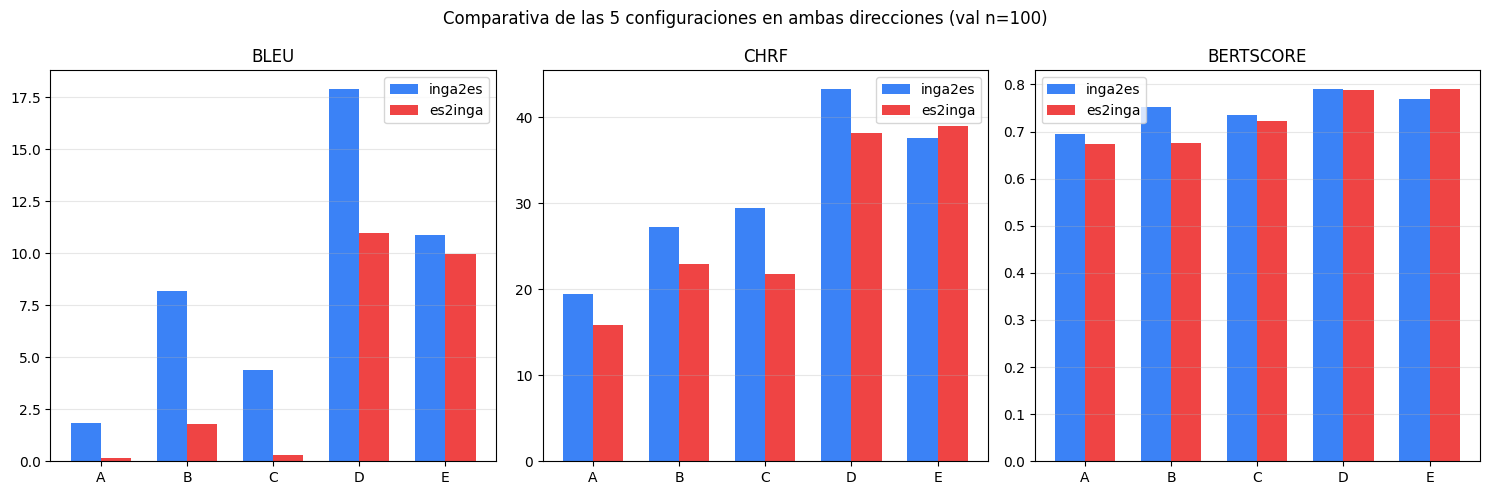

Figura: /Users/william-santos/Documents/UNIR/tfm/entrega2/figuras/fig12_metricas_comparativas.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

configs = ["A", "B", "C", "D", "E"]
metricas = ["bleu", "chrf", "bertscore"]
direcciones = ["inga2es", "es2inga"]

key_map = {
    "A": ("config_A_nllb_zeroshot_inga2es", "config_A_nllb_zeroshot_es2inga"),
    "B": ("config_B_nllb_lora_inga2es", "config_B_nllb_lora_es2inga"),
    "C": ("config_C_claude_zeroshot_inga2es", "config_C_claude_zeroshot_es2inga"),
    "D": ("config_D_claude_rag_inga2es", "config_D_claude_rag_es2inga"),
    "E": ("config_E_lora_plus_claude_rag_inga2es", "config_E_lora_plus_claude_rag_es2inga"),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, metricas):
    x = np.arange(len(configs))
    width = 0.35
    vals_i2e = [resultados.get(key_map[c][0], {}).get(metric, 0) or 0 for c in configs]
    vals_e2i = [resultados.get(key_map[c][1], {}).get(metric, 0) or 0 for c in configs]
    ax.bar(x - width/2, vals_i2e, width, label="inga2es", color="#3b82f6")
    ax.bar(x + width/2, vals_e2i, width, label="es2inga", color="#ef4444")
    ax.set_xticks(x)
    ax.set_xticklabels(configs)
    ax.set_title(f"{metric.upper()}")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
fig.suptitle("Comparativa de las 5 configuraciones en ambas direcciones (val n=100)")
fig.tight_layout()
OUT_FIG = ROOT / "entrega2" / "figuras" / "fig12_metricas_comparativas.png"
OUT_FIG.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT_FIG, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura: {OUT_FIG}")
